# x86 CPU Governor — MLP Students and Student-Warmed Dual-Frequency DDQN

This notebook preserves the core architecture of `CPU_Governor_Combined_Pipeline(1).ipynb`, with three deliberate changes:

1. **x86 only:** configuration, frequency modelling, EDP evaluation, and RL all use the x86 measurements.
2. **MLP students only:** the configuration student is a score-producing MLP; the frequency student is a 32×32 MLP. No LUT is used.
3. **Students-only agent warming:** the dual-head discrete-frequency DDQN receives its 50-action configuration reward surface from the configuration MLP and its frequency imitation targets from the frequency MLP. The agent never queries either teacher.

The experimental unit is a targeted-utilisation state. All headline results use leakage-safe leave-one-state-out evaluation and three RL seeds.


## 1. Context, assumptions, and configuration

### Key assumptions

- EDP is computed as `Measured MRT² × Measured CORE Power` per run and aggregated by the median.
- The 50 actions are the measured `(sampling rate, threshold)` combinations.
- The data contain a full action surface per state, not temporal transitions. Therefore `gamma=0`; this is contextual-bandit warming, not sequential online RL.
- Frequency was observed rather than independently commanded. It is used only as a student-imitation target, not as a fabricated frequency-dependent EDP reward.


In [1]:
from __future__ import annotations

import re, time, warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, Sequence, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})


@dataclass
class CFG:
    remote_url: str = "https://raw.githubusercontent.com/akillis-mo/PPDS-project/main/data/x86_mm1_clean.csv"
    local_csv: str = "data/x86_mm1_clean.csv"
    seed: int = 42
    rl_seeds: Tuple[int, ...] = (7, 42, 123)
    sampling_rates: Tuple[int, ...] = tuple(range(10_000, 100_001, 10_000))
    thresholds: Tuple[int, ...] = (75, 80, 85, 90, 95)
    ondemand_sr: int = 10_000
    ondemand_thr: int = 95
    rho_eps: float = 1e-3
    fmin_khz: float = 800_000.0
    fmax_khz: float = 2_100_000.0

    config_student_hidden: Tuple[int, ...] = (64, 64)
    config_distill_points: int = 256
    config_student_epochs: int = 1_400
    config_student_lr: float = 2e-3

    freq_expert_C: float = 100.0
    freq_expert_gamma: float = 0.1
    freq_expert_epsilon: float = 5e-3
    freq_student_hidden: Tuple[int, ...] = (32, 32)
    freq_distill_points: int = 64
    freq_student_epochs: int = 900
    freq_student_lr: float = 5e-3

    gamma: float = 0.0
    rl_grid_points: int = 96
    rl_steps: int = 2_000
    rl_batch: int = 128
    rl_lr: float = 3e-3
    rl_hidden: Tuple[int, ...] = (48, 48)
    rl_target_tau: float = 0.05
    rl_eps_start: float = 1.0
    rl_eps_end: float = 0.05
    n_frequency_bins: int = 32
    lambda_frequency: float = 2.0
    results_dir: str = "results_x86_mlp_students_ddqn"


CFG_ = CFG()
RESULTS = Path(CFG_.results_dir)
RESULTS.mkdir(parents=True, exist_ok=True)
np.random.seed(CFG_.seed)
print("Configuration loaded. Student-only warming is enforced below.")


Configuration loaded. Student-only warming is enforced below.


## 2. Load and prepare x86 data


In [2]:
CANONICAL = {
    "util_target_pct": ["cpuutilization", "targetedutilization", "targetutilization"],
    "sampling_rate_us": ["samplingrate"],
    "threshold_pct": ["threshold"],
    "mrt_ms": ["measuredmrt"],
    "power_w": ["measuredcorepower"],
    "freq_khz": ["measuredmeancorefrequency"],
    "measured_util_pct": ["measuredutilization"],
}


def norm_name(name):
    s = re.sub(r"\[.*?\]|\(.*?\)", " ", str(name))
    return re.sub(r"[^0-9a-zA-Z]+", "", s.replace("µ", "u")).lower()


def resolve_columns(df):
    lookup = {norm_name(c): c for c in df.columns}
    out = {}
    for key, candidates in CANONICAL.items():
        for candidate in candidates:
            if candidate in lookup:
                out[key] = lookup[candidate]
                break
    missing = sorted(set(CANONICAL) - set(out))
    if missing:
        raise KeyError(f"Missing columns: {missing}; available={list(df.columns)}")
    return out


try:
    raw = pd.read_csv(CFG_.remote_url)
    DATA_SOURCE = CFG_.remote_url
except Exception:
    raw = pd.read_csv(CFG_.local_csv)
    DATA_SOURCE = CFG_.local_csv

cols = resolve_columns(raw)
runs = pd.DataFrame({key: pd.to_numeric(raw[col], errors="coerce") for key, col in cols.items()})
runs = runs.dropna().copy()
runs["sampling_rate_us"] = runs["sampling_rate_us"].astype(int)
runs["threshold_pct"] = runs["threshold_pct"].astype(int)
runs["util_target_pct"] = runs["util_target_pct"].round(6)
runs["edp"] = runs["mrt_ms"] ** 2 * runs["power_w"]

ACTION_GRID = pd.DataFrame(
    [(sr, thr) for sr in CFG_.sampling_rates for thr in CFG_.thresholds],
    columns=["sampling_rate_us", "threshold_pct"],
)
ACTION_GRID.insert(0, "config_id", np.arange(len(ACTION_GRID)))
ACTION_GRID["sr_norm"] = (ACTION_GRID.sampling_rate_us - min(CFG_.sampling_rates)) / (max(CFG_.sampling_rates) - min(CFG_.sampling_rates))
ACTION_GRID["thr_norm"] = (ACTION_GRID.threshold_pct - min(CFG_.thresholds)) / (max(CFG_.thresholds) - min(CFG_.thresholds))
N_ACTIONS = len(ACTION_GRID)
SR_ARR = ACTION_GRID.sampling_rate_us.to_numpy()
THR_ARR = ACTION_GRID.threshold_pct.to_numpy()
SRN_ARR = ACTION_GRID.sr_norm.to_numpy()
THRN_ARR = ACTION_GRID.thr_norm.to_numpy()
ONDEMAND_ID = int(ACTION_GRID.query("sampling_rate_us == @CFG_.ondemand_sr and threshold_pct == @CFG_.ondemand_thr").config_id.iloc[0])
assert N_ACTIONS == 50

keys = ["util_target_pct", "sampling_rate_us", "threshold_pct"]
TABLE = (runs.groupby(keys)
         .agg(edp=("edp", "median"), freq_khz=("freq_khz", "median"), measured_util_pct=("measured_util_pct", "median"), n_reps=("edp", "size"))
         .reset_index().merge(ACTION_GRID, on=["sampling_rate_us", "threshold_pct"], how="left"))
TABLE["log_edp"] = np.log10(TABLE.edp)
TABLE["state_id"] = "x86@" + TABLE.util_target_pct.map(lambda v: f"{v:g}")

state_rows = []
for util, g in TABLE.groupby("util_target_pct"):
    if set(g.config_id.astype(int)) != set(range(N_ACTIONS)):
        continue
    ond = g[g.config_id == ONDEMAND_ID].iloc[0]
    oracle = g.loc[g.edp.idxmin()]
    rho = float(np.clip(ond.measured_util_pct / 100, CFG_.rho_eps, 1-CFG_.rho_eps))
    state_rows.append(dict(state_id=f"x86@{util:g}", util_target_pct=float(util), rho=rho,
                           log_1m_rho=float(np.log10(max(1-rho, CFG_.rho_eps))),
                           oracle_config_id=int(oracle.config_id), edp_oracle=float(oracle.edp),
                           edp_ondemand=float(ond.edp)))
STATES = pd.DataFrame(state_rows).sort_values("util_target_pct").reset_index(drop=True)
STATE_ROW = STATES.set_index("state_id")
STATE_IDS = STATES.state_id.tolist()
assert len(STATE_IDS) == 10

TABLE = TABLE[TABLE.state_id.isin(STATE_IDS)].merge(STATES[["util_target_pct", "rho", "log_1m_rho"]], on="util_target_pct", how="left")
EDP_MATRIX = TABLE.pivot(index="state_id", columns="config_id", values="edp").reindex(index=STATE_IDS, columns=range(N_ACTIONS))
FREQ_MATRIX = TABLE.pivot(index="state_id", columns="config_id", values="freq_khz").reindex(index=STATE_IDS, columns=range(N_ACTIONS))

print(f"Source: {DATA_SOURCE}")
print(f"Runs={len(runs):,}; complete states={len(STATES)}; actions/state={N_ACTIONS}; aggregated rows={len(TABLE)}")
print(STATES.assign(ondemand_regret=STATES.edp_ondemand/STATES.edp_oracle-1)[["state_id","rho","oracle_config_id","ondemand_regret"]].to_string(index=False))


Source: https://raw.githubusercontent.com/akillis-mo/PPDS-project/main/data/x86_mm1_clean.csv
Runs=4,979; complete states=10; actions/state=50; aggregated rows=500
state_id    rho  oracle_config_id  ondemand_regret
  x86@10 0.1047                 0           0.3565
  x86@20 0.2060                 0           0.3031
  x86@30 0.3122                 0           0.2748
  x86@40 0.4162                 0           0.1785
  x86@50 0.5160                43           0.1627
  x86@60 0.6269                35           0.1150
  x86@70 0.7159                45           0.2122
  x86@80 0.8278                32           0.2551
  x86@90 0.9231                39           0.1533
 x86@100 0.9755                29           3.6524


## 3. Shared deterministic MLP implementation


In [3]:
class MLP:
    def __init__(self, sizes: Sequence[int], out_act="linear", seed=0, lr=3e-3):
        rng = np.random.default_rng(seed)
        self.sizes, self.out_act, self.lr = list(sizes), out_act, lr
        self.W = [rng.normal(0, np.sqrt(1/a), (a,b)) for a,b in zip(self.sizes[:-1], self.sizes[1:])]
        self.b = [np.zeros(b) for b in self.sizes[1:]]
        self._reset_adam()

    def _reset_adam(self):
        self.mW=[np.zeros_like(w) for w in self.W]; self.vW=[np.zeros_like(w) for w in self.W]
        self.mb=[np.zeros_like(b) for b in self.b]; self.vb=[np.zeros_like(b) for b in self.b]; self.t=0

    def forward(self, X, cache=False):
        A=np.asarray(X,dtype=float); acts=[A]
        for i,(W,b) in enumerate(zip(self.W,self.b)):
            Z=A@W+b
            if i < len(self.W)-1: A=np.tanh(Z)
            elif self.out_act=="sigmoid": A=1/(1+np.exp(-np.clip(Z,-30,30)))
            elif self.out_act=="tanh": A=np.tanh(Z)
            else: A=Z
            acts.append(A)
        if cache: self._acts=acts
        return A

    __call__=forward

    def backward(self,dY):
        acts=self._acts; dW=[None]*len(self.W); db=[None]*len(self.b); Y=acts[-1]
        if self.out_act=="sigmoid": dZ=dY*Y*(1-Y)
        elif self.out_act=="tanh": dZ=dY*(1-Y**2)
        else: dZ=dY
        for i in range(len(self.W)-1,-1,-1):
            dW[i]=acts[i].T@dZ; db[i]=dZ.sum(0); dA=dZ@self.W[i].T
            dZ=dA*(1-acts[i]**2) if i>0 else dA
        return dW,db,dZ

    def adam_step(self,dW,db,lr=None,b1=.9,b2=.999,eps=1e-8):
        self.t+=1; lr=self.lr if lr is None else lr
        for i in range(len(self.W)):
            self.mW[i]=b1*self.mW[i]+(1-b1)*dW[i]; self.vW[i]=b2*self.vW[i]+(1-b2)*dW[i]**2
            self.mb[i]=b1*self.mb[i]+(1-b1)*db[i]; self.vb[i]=b2*self.vb[i]+(1-b2)*db[i]**2
            self.W[i]-=lr*(self.mW[i]/(1-b1**self.t))/(np.sqrt(self.vW[i]/(1-b2**self.t))+eps)
            self.b[i]-=lr*(self.mb[i]/(1-b1**self.t))/(np.sqrt(self.vb[i]/(1-b2**self.t))+eps)

    def fit_regression(self,X,Y,epochs,batch=256,seed=0):
        X=np.asarray(X,float); Y=np.asarray(Y,float).reshape(len(X),-1); rng=np.random.default_rng(seed)
        for _ in range(epochs):
            for start in range(0,len(X),batch):
                ix=rng.permutation(len(X))[start:start+batch]
                pred=self.forward(X[ix],cache=True)
                dW,db,_=self.backward(2*(pred-Y[ix])/(len(ix)*Y.shape[1]))
                self.adam_step(dW,db)
        return self

    def copy(self):
        o=MLP(self.sizes,self.out_act,0,self.lr); o.W=[w.copy() for w in self.W]; o.b=[b.copy() for b in self.b]; return o

    def soft_update_from(self,src,tau):
        for i in range(len(self.W)):
            self.W[i]=(1-tau)*self.W[i]+tau*src.W[i]; self.b[i]=(1-tau)*self.b[i]+tau*src.b[i]

    @property
    def n_params(self): return int(sum(w.size for w in self.W)+sum(b.size for b in self.b))

print("MLP implementation ready.")


MLP implementation ready.


## 4. Configuration teacher and score-producing MLP student

The PCHIP teacher predicts relative log-EDP for all 50 actions. The configuration MLP is distilled on a dense utilisation grid and preserves a **complete score vector**, making it suitable for student-only DDQN warming.


In [4]:
class PCHIPConfigurationTeacher:
    def fit(self, table):
        self.rho_min=float(table.rho.min()); self.rho_max=float(table.rho.max()); self.curves={}
        baseline=table[table.config_id==ONDEMAND_ID].set_index("util_target_pct").log_edp
        for cid,g in table.groupby("config_id"):
            x=g.log_1m_rho.to_numpy(); y=g.log_edp.to_numpy()-g.util_target_pct.map(baseline).to_numpy(); order=np.argsort(x)
            self.curves[int(cid)]=PchipInterpolator(x[order],y[order],extrapolate=True)
        return self
    def score(self,rho):
        x=np.log10(np.clip(1-np.atleast_1d(rho),CFG_.rho_eps,None))
        return np.column_stack([self.curves[c](x) for c in range(N_ACTIONS)])
    def predict_config(self,rho): return np.argmin(self.score(rho),axis=1)


def state_features(rho):
    r=np.atleast_1d(np.asarray(rho,float)); return np.column_stack([r,np.log10(np.clip(1-r,CFG_.rho_eps,None))])


class ConfigurationScoreMLPStudent:
    # Returns a reward-like score for every configuration; higher is better.
    def __init__(self,seed=42):
        self.net=MLP([2,*CFG_.config_student_hidden,N_ACTIONS],"linear",seed,CFG_.config_student_lr)
    def distill(self,teacher):
        rho=np.linspace(teacher.rho_min,teacher.rho_max,CFG_.config_distill_points); X=state_features(rho)
        self.xmu=X.mean(0,keepdims=True); self.xsd=X.std(0,keepdims=True)+1e-9
        q=-teacher.score(rho); q=(q-q.mean(1,keepdims=True))/(q.std(1,keepdims=True)+1e-9)
        self.net.fit_regression((X-self.xmu)/self.xsd,q,CFG_.config_student_epochs,batch=128,seed=CFG_.seed)
        self.rho_min,self.rho_max=teacher.rho_min,teacher.rho_max
        return self
    def score(self,rho):
        X=(state_features(rho)-self.xmu)/self.xsd; return self.net.forward(X)
    def predict_config(self,rho): return np.argmax(self.score(rho),axis=1)


def fit_config_stack(train_ids):
    train=TABLE[TABLE.state_id.isin(train_ids)]
    teacher=PCHIPConfigurationTeacher().fit(train)
    student=ConfigurationScoreMLPStudent(CFG_.seed).distill(teacher)
    return teacher,student

print("Configuration teacher and MLP student defined.")


Configuration teacher and MLP student defined.


## 5. Frequency teacher and 32×32 MLP student

The x86 RBF-SVR teacher predicts normalized legal frequency. The frequency MLP distils it on a dense `(utilisation × action)` grid and uses a sigmoid output, so every prediction remains inside x86's legal range.


In [5]:
FREQ_FEATURES=["rho","log_1m_rho","sr_norm","thr_norm"]

def freq_features(rho,srn,thrn):
    rho=np.atleast_1d(np.asarray(rho,float)); srn=np.atleast_1d(np.asarray(srn,float)); thrn=np.atleast_1d(np.asarray(thrn,float))
    rho,srn,thrn=np.broadcast_arrays(rho,srn,thrn)
    return np.column_stack([rho.ravel(),np.log10(np.clip(1-rho.ravel(),CFG_.rho_eps,None)),srn.ravel(),thrn.ravel()])


class FrequencyTeacher:
    def __init__(self):
        self.model=Pipeline([("scale",StandardScaler()),("svr",SVR(kernel="rbf",C=CFG_.freq_expert_C,gamma=CFG_.freq_expert_gamma,
            epsilon=CFG_.freq_expert_epsilon,tol=1e-3,max_iter=-1,cache_size=500))])
    def fit(self,table):
        X=table[FREQ_FEATURES].to_numpy(); y=(table.freq_khz-CFG_.fmin_khz)/(CFG_.fmax_khz-CFG_.fmin_khz)
        self.model.fit(X,y); self.rho_min=float(table.rho.min()); self.rho_max=float(table.rho.max()); return self
    def predict_norm(self,rho,srn,thrn): return np.clip(self.model.predict(freq_features(rho,srn,thrn)),0,1)
    def predict_grid_norm(self,rho): return self.predict_norm(np.full(N_ACTIONS,rho),SRN_ARR,THRN_ARR)


class FrequencyMLPStudent:
    def __init__(self,seed=42):
        self.net=MLP([4,*CFG_.freq_student_hidden,1],"sigmoid",seed,CFG_.freq_student_lr)
    def distill(self,teacher):
        rg=np.linspace(teacher.rho_min,teacher.rho_max,CFG_.freq_distill_points)
        X=freq_features(np.repeat(rg,N_ACTIONS),np.tile(SRN_ARR,len(rg)),np.tile(THRN_ARR,len(rg)))
        y=teacher.model.predict(X).clip(0,1).reshape(-1,1)
        self.net.fit_regression(X,y,CFG_.freq_student_epochs,batch=512,seed=CFG_.seed); return self
    def predict_norm(self,rho,srn,thrn): return self.net.forward(freq_features(rho,srn,thrn)).ravel().clip(0,1)
    def predict_grid_norm(self,rho): return self.predict_norm(np.full(N_ACTIONS,rho),SRN_ARR,THRN_ARR)
    def predict_grid_khz(self,rho): return CFG_.fmin_khz+self.predict_grid_norm(rho)*(CFG_.fmax_khz-CFG_.fmin_khz)


def fit_frequency_stack(train_ids):
    train=TABLE[TABLE.state_id.isin(train_ids)].copy()
    train["f_norm"]=(train.freq_khz-CFG_.fmin_khz)/(CFG_.fmax_khz-CFG_.fmin_khz)
    teacher=FrequencyTeacher().fit(train)
    student=FrequencyMLPStudent(CFG_.seed).distill(teacher)
    return teacher,student

print("Frequency teacher and MLP student defined.")


Frequency teacher and MLP student defined.


## 6. Leakage-safe student evaluation


In [6]:
def policy_row(sid,policy,cid):
    row=STATE_ROW.loc[sid]; edp=float(EDP_MATRIX.loc[sid,cid])
    return dict(state_id=sid,policy=policy,config_id=int(cid),regret=edp/row.edp_oracle-1,
                delta_vs_ondemand=edp/row.edp_ondemand-1,exact_oracle=int(cid)==int(row.oracle_config_id))

CONFIG_ASSETS={}; FREQ_ASSETS={}; config_rows=[]; freq_rows=[]
for sid in STATE_IDS:
    train_ids=[s for s in STATE_IDS if s!=sid]
    ct,cs=fit_config_stack(train_ids); ft,fs=fit_frequency_stack(train_ids)
    CONFIG_ASSETS[sid]={"teacher":ct,"student":cs}; FREQ_ASSETS[sid]={"teacher":ft,"student":fs}
    rho=float(STATE_ROW.loc[sid,"rho"])
    config_rows += [policy_row(sid,"Oracle",int(STATE_ROW.loc[sid,"oracle_config_id"])),
                    policy_row(sid,"Linux Ondemand",ONDEMAND_ID),
                    policy_row(sid,"PCHIP Teacher",int(ct.predict_config(rho)[0])),
                    policy_row(sid,"MLP Configuration Student",int(cs.predict_config(rho)[0]))]
    measured=FREQ_MATRIX.loc[sid].to_numpy(float); tp=CFG_.fmin_khz+ft.predict_grid_norm(rho)*(CFG_.fmax_khz-CFG_.fmin_khz); sp=fs.predict_grid_khz(rho)
    for cid in range(N_ACTIONS):
        freq_rows.append(dict(state_id=sid,config_id=cid,measured_khz=measured[cid],teacher_khz=tp[cid],student_khz=sp[cid]))

CONFIG_LOOCV=pd.DataFrame(config_rows); FREQ_LOOCV=pd.DataFrame(freq_rows)

def config_metrics(g):
    return dict(mean_regret=g.regret.mean(),median_regret=g.regret.median(),worst_regret=g.regret.max(),
                exact_oracle_rate=g.exact_oracle.mean(),within_5pct_oracle=(g.regret<=.05).mean(),
                mean_delta_vs_ondemand=g.delta_vs_ondemand.mean(),better_than_ondemand=(g.delta_vs_ondemand<0).mean())

CONFIG_SUMMARY=pd.DataFrame([{"policy":p,**config_metrics(g)} for p,g in CONFIG_LOOCV.groupby("policy")]).sort_values("mean_regret")

def freq_metrics(col):
    e=FREQ_LOOCV[col]-FREQ_LOOCV.measured_khz
    return dict(model=col.replace("_khz","").title(),MAE_MHz=np.abs(e).mean()/1e3,RMSE_MHz=np.sqrt(np.mean(e**2))/1e3,
                R2=r2_score(FREQ_LOOCV.measured_khz,FREQ_LOOCV[col]),legal_violation_pct=100*np.mean((FREQ_LOOCV[col]<CFG_.fmin_khz)|(FREQ_LOOCV[col]>CFG_.fmax_khz)))
FREQ_SUMMARY=pd.DataFrame([freq_metrics("teacher_khz"),freq_metrics("student_khz")])

print("CONFIGURATION RESULTS")
print(CONFIG_SUMMARY.to_string(index=False))
print("\nFREQUENCY RESULTS")
print(FREQ_SUMMARY.to_string(index=False))


CONFIGURATION RESULTS
                   policy  mean_regret  median_regret  worst_regret  exact_oracle_rate  within_5pct_oracle  mean_delta_vs_ondemand  better_than_ondemand
                   Oracle       0.0000         0.0000        0.0000             1.0000              1.0000                 -0.2402                1.0000
            PCHIP Teacher       0.0693         0.0390        0.1952             0.3000              0.6000                 -0.1909                1.0000
MLP Configuration Student       0.1248         0.0236        0.8733             0.4000              0.7000                 -0.1892                1.0000
           Linux Ondemand       0.5664         0.2337        3.6524             0.0000              0.0000                  0.0000                0.0000

FREQUENCY RESULTS
  model  MAE_MHz  RMSE_MHz     R2  legal_violation_pct
Teacher  54.2501  119.7795 0.1957               0.0000
Student  18.4551   36.7007 0.9245               0.0000


## 7. Student-only warming surface

This cell is the enforcement point. `make_student_surface` accepts **only** the two student objects. Its configuration matrix `Q` is generated by `ConfigurationScoreMLPStudent.score`; its frequency matrix `Fnorm` is generated by `FrequencyMLPStudent.predict_grid_norm`.


In [7]:
@dataclass
class StudentSurface:
    state_id:str; mu:np.ndarray; sd:np.ndarray; S:np.ndarray; rho_grid:np.ndarray; Q:np.ndarray; Fnorm:np.ndarray
    def encode(self,rho):
        X=state_features(rho); return (X-self.mu)/self.sd


def make_student_surface(config_student:ConfigurationScoreMLPStudent,freq_student:FrequencyMLPStudent,state_id="fold"):
    lo=max(config_student.rho_min,CFG_.rho_eps); hi=min(config_student.rho_max,1-CFG_.rho_eps)
    rho=np.linspace(lo,hi,CFG_.rl_grid_points); raw=state_features(rho); mu=raw.mean(0,keepdims=True); sd=raw.std(0,keepdims=True)+1e-9
    Q=config_student.score(rho); Q=(Q-Q.mean())/(Q.std()+1e-9)
    F=np.vstack([freq_student.predict_grid_norm(r) for r in rho])
    return StudentSurface(state_id,mu,sd,(raw-mu)/sd,rho,Q,F)


def build_surface(sid):
    return make_student_surface(CONFIG_ASSETS[sid]["student"],FREQ_ASSETS[sid]["student"],sid)

probe=build_surface(STATE_IDS[0])
assert probe.Q.shape==(CFG_.rl_grid_points,N_ACTIONS) and probe.Fnorm.shape==probe.Q.shape
print(f"Student-only surface: states={probe.S.shape}, config scores={probe.Q.shape}, frequency targets={probe.Fnorm.shape}")
print("Teachers are absent from the warming function signature and data path.")


Student-only surface: states=(96, 2), config scores=(96, 50), frequency targets=(96, 50)
Teachers are absent from the warming function signature and data path.


## 8. Dual-head discrete-frequency DDQN

The agent has a shared state trunk, a 50-action configuration head, and a configuration-conditioned frequency head over 32 legal bins. With `gamma=0`, DDQN target-network machinery is retained for architectural continuity, but no next-state reward is invented.


In [8]:
class FactorisedQNet:
    def __init__(self,in_dim,n_actions,n_bins,seed):
        h=CFG_.rl_hidden[0]
        self.trunk=MLP([in_dim,h],"tanh",seed,CFG_.rl_lr)
        self.chead=MLP([h,*CFG_.rl_hidden[1:],n_actions],"linear",seed+1,CFG_.rl_lr)
        self.fhead=MLP([h+2,*CFG_.rl_hidden[1:],n_bins],"linear",seed+2,CFG_.rl_lr)
        self.n_bins=n_bins
    def q_config(self,S,cache=False): return self.chead.forward(self.trunk.forward(S,cache=cache),cache=cache)
    def q_freq(self,S,cid,cache=False):
        H=self.trunk.forward(S,cache=cache); X=np.column_stack([H,SRN_ARR[cid],THRN_ARR[cid]])
        return self.fhead.forward(X,cache=cache)
    def step_config(self,S,a,y):
        Q=self.q_config(S,True); d=np.zeros_like(Q); d[np.arange(len(S)),a]=2*(Q[np.arange(len(S)),a]-y)/len(S)
        dw,db,dh=self.chead.backward(d); dwt,dbt,_=self.trunk.backward(dh); self.chead.adam_step(dw,db); self.trunk.adam_step(dwt,dbt)
    def step_freq(self,S,c,b,y):
        Q=self.q_freq(S,c,True); d=np.zeros_like(Q); d[np.arange(len(S)),b]=2*(Q[np.arange(len(S)),b]-y)/len(S)
        dw,db,dx=self.fhead.backward(d); dwt,dbt,_=self.trunk.backward(dx[:,:-2]); self.fhead.adam_step(dw,db); self.trunk.adam_step(dwt,dbt)
    def copy(self):
        o=FactorisedQNet.__new__(FactorisedQNet); o.trunk=self.trunk.copy(); o.chead=self.chead.copy(); o.fhead=self.fhead.copy(); o.n_bins=self.n_bins; return o
    def soft_update_from(self,src,tau):
        self.trunk.soft_update_from(src.trunk,tau); self.chead.soft_update_from(src.chead,tau); self.fhead.soft_update_from(src.fhead,tau)
    @property
    def n_params(self): return self.trunk.n_params+self.chead.n_params+self.fhead.n_params


def bin_centers(n=CFG_.n_frequency_bins):
    e=np.linspace(CFG_.fmin_khz,CFG_.fmax_khz,n+1); return .5*(e[:-1]+e[1:])


def train_student_ddqn(surface,seed):
    rng=np.random.default_rng(seed); centers=bin_centers(); cn=(centers-CFG_.fmin_khz)/(CFG_.fmax_khz-CFG_.fmin_khz)
    Rf=-(cn[None,None,:]-surface.Fnorm[:,:,None])**2
    Rc=surface.Q+CFG_.lambda_frequency*Rf.max(2)
    online=FactorisedQNet(surface.S.shape[1],N_ACTIONS,len(centers),seed); target=online.copy(); G=len(surface.S)
    for step in range(CFG_.rl_steps):
        eps=CFG_.rl_eps_end+(CFG_.rl_eps_start-CFG_.rl_eps_end)*(1-step/max(1,CFG_.rl_steps))
        gi=rng.integers(0,G,CFG_.rl_batch); S=surface.S[gi]
        gc=np.argmax(online.q_config(S),1); c=np.where(rng.random(CFG_.rl_batch)<eps,rng.integers(0,N_ACTIONS,CFG_.rl_batch),gc)
        yc=Rc[gi,c]+CFG_.gamma*target.q_config(S)[np.arange(CFG_.rl_batch),np.argmax(online.q_config(S),1)]
        online.step_config(S,c,yc)
        gb=np.argmax(online.q_freq(S,c),1); b=np.where(rng.random(CFG_.rl_batch)<eps,rng.integers(0,len(centers),CFG_.rl_batch),gb)
        yf=CFG_.lambda_frequency*Rf[gi,c,b]+CFG_.gamma*target.q_freq(S,c)[np.arange(CFG_.rl_batch),np.argmax(online.q_freq(S,c),1)]
        online.step_freq(S,c,b,yf); target.soft_update_from(online,CFG_.rl_target_tau)
    return online,centers


def agent_action(net,centers,surface,rho):
    S=surface.encode(rho); cid=int(np.argmax(net.q_config(S),1)[0]); bid=int(np.argmax(net.q_freq(S,np.array([cid])),1)[0])
    return dict(config_id=cid,sampling_rate_us=int(SR_ARR[cid]),threshold_pct=int(THR_ARR[cid]),frequency_bin_id=bid,frequency_khz=float(centers[bid]))

print("Dual-head student-warmed DDQN defined.")


Dual-head student-warmed DDQN defined.


## 9. Leave-one-state-out agent evaluation


In [9]:
rl_rows=[]; fold_times=[]
for i,sid in enumerate(STATE_IDS,1):
    t0=time.perf_counter(); surface=build_surface(sid); rho=float(STATE_ROW.loc[sid,"rho"])
    for seed in CFG_.rl_seeds:
        net,centers=train_student_ddqn(surface,seed); act=agent_action(net,centers,surface,rho); cid=act["config_id"]
        row=STATE_ROW.loc[sid]; edp=float(EDP_MATRIX.loc[sid,cid]); measured=float(FREQ_MATRIX.loc[sid,cid]); target=float(FREQ_ASSETS[sid]["student"].predict_grid_khz(rho)[cid])
        rl_rows.append(dict(state_id=sid,seed=seed,**act,regret=edp/row.edp_oracle-1,delta_vs_ondemand=edp/row.edp_ondemand-1,
                            exact_oracle=cid==int(row.oracle_config_id),freq_student_khz=target,freq_measured_khz=measured,
                            freq_err_vs_student_khz=abs(act["frequency_khz"]-target),freq_err_vs_measured_khz=abs(act["frequency_khz"]-measured),
                            freq_legal=CFG_.fmin_khz<=act["frequency_khz"]<=CFG_.fmax_khz))
    fold_times.append(time.perf_counter()-t0); print(f"fold {i:02d}/10 {sid} complete in {fold_times[-1]:.1f}s")

RL_LOOCV=pd.DataFrame(rl_rows)

def agent_metrics(df):
    per=[]
    for seed,g in df.groupby("seed"):
        per.append(config_metrics(g))
    out={k:float(np.mean([x[k] for x in per])) for k in per[0]}
    out["seed_std_mean_regret"]=float(np.std([x["mean_regret"] for x in per]))
    return out

AGENT_METRICS=agent_metrics(RL_LOOCV)
AGENT_FREQ_METRICS=dict(MAE_vs_student_MHz=RL_LOOCV.freq_err_vs_student_khz.mean()/1e3,
                        MAE_vs_measured_MHz=RL_LOOCV.freq_err_vs_measured_khz.mean()/1e3,
                        legal_violation_pct=100*(1-RL_LOOCV.freq_legal.mean()))

master=CONFIG_SUMMARY.copy()
master=pd.concat([master,pd.DataFrame([{"policy":"Student-warmed Dual-frequency DDQN",**AGENT_METRICS}])],ignore_index=True).sort_values("mean_regret")
print("MASTER X86 CONFIGURATION/AGENT RESULTS")
print(master.to_string(index=False))
print("\nAGENT FREQUENCY RESULTS")
print(pd.DataFrame([AGENT_FREQ_METRICS]).to_string(index=False))


fold 01/10 x86@10 complete in 7.3s
fold 02/10 x86@20 complete in 7.0s
fold 03/10 x86@30 complete in 6.9s
fold 04/10 x86@40 complete in 7.5s
fold 05/10 x86@50 complete in 7.0s
fold 06/10 x86@60 complete in 6.7s
fold 07/10 x86@70 complete in 7.1s
fold 08/10 x86@80 complete in 7.2s
fold 09/10 x86@90 complete in 7.4s
fold 10/10 x86@100 complete in 7.1s
MASTER X86 CONFIGURATION/AGENT RESULTS
                            policy  mean_regret  median_regret  worst_regret  exact_oracle_rate  within_5pct_oracle  mean_delta_vs_ondemand  better_than_ondemand  seed_std_mean_regret
                            Oracle       0.0000         0.0000        0.0000             1.0000              1.0000                 -0.2402                1.0000                   NaN
                     PCHIP Teacher       0.0693         0.0390        0.1952             0.3000              0.6000                 -0.1909                1.0000                   NaN
         MLP Configuration Student       0.1248         0.

## 10. Latency, checks, and visual evidence


LATENCY
                             model  median_ms  p95_ms  p99_ms
         MLP Configuration Student     0.0147  0.0495  0.1024
       32x32 Frequency MLP Student     0.0327  0.0657  0.1089
Student-warmed Dual-frequency DDQN     0.0265  0.0547  0.0830
[x] x86 only
[x] 50 actions per state
[x] configuration student is MLP
[x] frequency student is MLP
[x] warming surface built only from students
[x] gamma is zero
[x] three seeds and ten held-out states
[x] all emitted frequencies legal
[x] no missing headline results


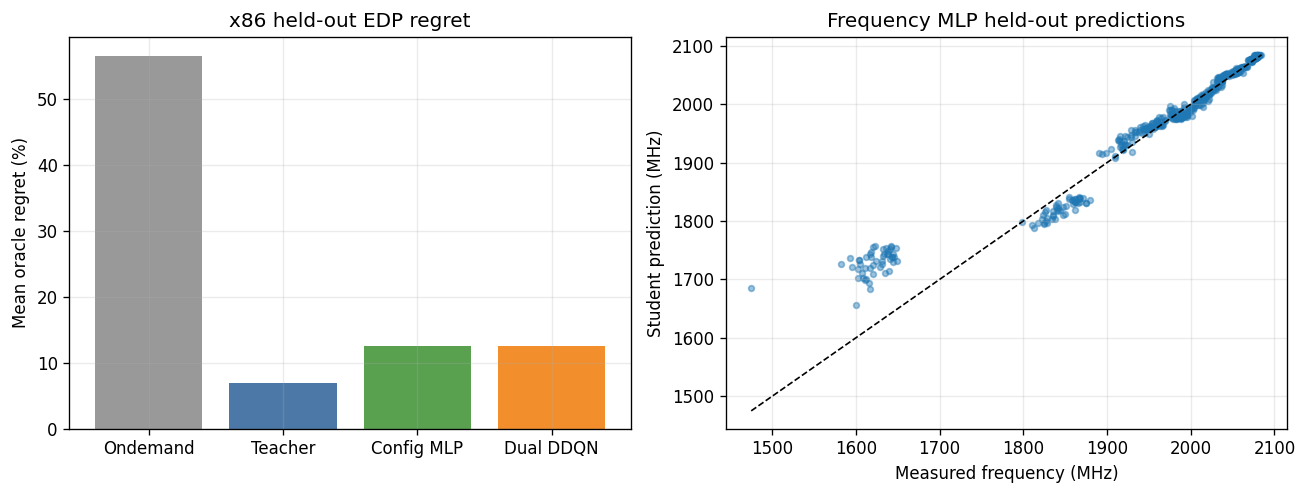

In [10]:
DEPLOY_CT,DEPLOY_CS=fit_config_stack(STATE_IDS); DEPLOY_FT,DEPLOY_FS=fit_frequency_stack(STATE_IDS)
DEPLOY_SURFACE=make_student_surface(DEPLOY_CS,DEPLOY_FS,"deployment")
DEPLOY_NET,DEPLOY_CENTERS=train_student_ddqn(DEPLOY_SURFACE,CFG_.seed)
DEMO_RHO=float(STATES.rho.median())

def bench(fn,n=500,warm=30):
    for _ in range(warm): fn()
    t=[]
    for _ in range(n):
        s=time.perf_counter(); fn(); t.append((time.perf_counter()-s)*1e3)
    return np.median(t),np.percentile(t,95),np.percentile(t,99)

LATENCY=pd.DataFrame([
    dict(model="MLP Configuration Student",**dict(zip(["median_ms","p95_ms","p99_ms"],bench(lambda:DEPLOY_CS.predict_config(DEMO_RHO))))),
    dict(model="32x32 Frequency MLP Student",**dict(zip(["median_ms","p95_ms","p99_ms"],bench(lambda:DEPLOY_FS.predict_grid_khz(DEMO_RHO))))),
    dict(model="Student-warmed Dual-frequency DDQN",**dict(zip(["median_ms","p95_ms","p99_ms"],bench(lambda:agent_action(DEPLOY_NET,DEPLOY_CENTERS,DEPLOY_SURFACE,DEMO_RHO))))),
])
print("LATENCY")
print(LATENCY.to_string(index=False))

CHECKS={
    "x86 only": set(TABLE.state_id.str.split("@").str[0])=={"x86"},
    "50 actions per state": TABLE.groupby("state_id").config_id.nunique().eq(50).all(),
    "configuration student is MLP": isinstance(DEPLOY_CS.net,MLP),
    "frequency student is MLP": isinstance(DEPLOY_FS.net,MLP),
    "warming surface built only from students": "teacher" not in make_student_surface.__code__.co_varnames,
    "gamma is zero": CFG_.gamma==0,
    "three seeds and ten held-out states": RL_LOOCV.seed.nunique()==3 and RL_LOOCV.state_id.nunique()==10,
    "all emitted frequencies legal": RL_LOOCV.freq_legal.all(),
    "no missing headline results": np.isfinite(RL_LOOCV[["regret","delta_vs_ondemand","frequency_khz"]]).all().all(),
}
for label,ok in CHECKS.items(): print(f"[{'x' if ok else ' '}] {label}")
assert all(CHECKS.values())

fig,ax=plt.subplots(1,2,figsize=(11,4.2))
plot_df=master.set_index("policy").loc[["Linux Ondemand","PCHIP Teacher","MLP Configuration Student","Student-warmed Dual-frequency DDQN"]]
ax[0].bar(["Ondemand","Teacher","Config MLP","Dual DDQN"],100*plot_df.mean_regret,color=["#999999","#4c78a8","#59a14f","#f28e2b"])
ax[0].set_ylabel("Mean oracle regret (%)"); ax[0].set_title("x86 held-out EDP regret")
ax[1].scatter(FREQ_LOOCV.measured_khz/1e3,FREQ_LOOCV.student_khz/1e3,s=12,alpha=.45)
lo=min(FREQ_LOOCV.measured_khz.min(),FREQ_LOOCV.student_khz.min())/1e3; hi=max(FREQ_LOOCV.measured_khz.max(),FREQ_LOOCV.student_khz.max())/1e3
ax[1].plot([lo,hi],[lo,hi],"k--",lw=1); ax[1].set_xlabel("Measured frequency (MHz)"); ax[1].set_ylabel("Student prediction (MHz)"); ax[1].set_title("Frequency MLP held-out predictions")
fig.tight_layout(); fig.savefig(RESULTS/"x86_mlp_students_summary.png",dpi=160); plt.show()


## 11. Performance report and findings

The executed report below is generated directly from the held-out result tables. It distinguishes configuration EDP quality from frequency imitation quality and states whether the new agent beats Linux Ondemand and its own student expert.


In [11]:
idx=master.set_index("policy")
agent=idx.loc["Student-warmed Dual-frequency DDQN"]
ond=idx.loc["Linux Ondemand"]
stu=idx.loc["MLP Configuration Student"]
teacher=idx.loc["PCHIP Teacher"]
agent_vs_ond=100*(agent.mean_regret-ond.mean_regret)
agent_vs_stu=100*(agent.mean_regret-stu.mean_regret)

print("FINAL FINDINGS — x86 MLP-STUDENT PIPELINE")
print(f"1. Configuration MLP: mean oracle regret={100*stu.mean_regret:.2f}%; teacher={100*teacher.mean_regret:.2f}%; Ondemand={100*ond.mean_regret:.2f}%.")
print(f"2. Student-warmed dual-frequency DDQN: mean oracle regret={100*agent.mean_regret:.2f}% (seed std={100*agent.seed_std_mean_regret:.2f} pp).")
print(f"3. Agent vs Ondemand: {abs(agent_vs_ond):.2f} percentage points {'better' if agent_vs_ond<0 else 'worse'} in mean oracle regret; it beats Ondemand in {100*agent.better_than_ondemand:.1f}% of held-out state/seed evaluations.")
print(f"4. Agent vs configuration MLP: {abs(agent_vs_stu):.2f} percentage points {'better' if agent_vs_stu<0 else 'worse'} in mean oracle regret.")
print(f"5. Frequency MLP held-out MAE={float(FREQ_SUMMARY.set_index('model').loc['Student','MAE_MHz']):.2f} MHz; agent frequency-bin MAE vs its student target={AGENT_FREQ_METRICS['MAE_vs_student_MHz']:.2f} MHz and vs measurement={AGENT_FREQ_METRICS['MAE_vs_measured_MHz']:.2f} MHz.")
print(f"6. Safety: legal-frequency violations={AGENT_FREQ_METRICS['legal_violation_pct']:.1f}%; agent median latency={float(LATENCY.set_index('model').loc['Student-warmed Dual-frequency DDQN','median_ms']):.4f} ms.")
print("7. Scope: these are leave-one-utilisation-state-out offline results on one x86 machine. gamma=0 means warm-start policy learning, not validated sequential or online governor control.")

master.to_csv(RESULTS/"master_results.csv",index=False)
FREQ_SUMMARY.to_csv(RESULTS/"frequency_student_results.csv",index=False)
RL_LOOCV.to_csv(RESULTS/"agent_per_state_seed.csv",index=False)
LATENCY.to_csv(RESULTS/"latency.csv",index=False)
print(f"\nResult tables saved under {RESULTS.resolve()}")


FINAL FINDINGS — x86 MLP-STUDENT PIPELINE
1. Configuration MLP: mean oracle regret=12.48%; teacher=6.93%; Ondemand=56.64%.
2. Student-warmed dual-frequency DDQN: mean oracle regret=12.48% (seed std=0.00 pp).
3. Agent vs Ondemand: 44.16 percentage points better in mean oracle regret; it beats Ondemand in 100.0% of held-out state/seed evaluations.
4. Agent vs configuration MLP: 0.00 percentage points worse in mean oracle regret.
5. Frequency MLP held-out MAE=18.46 MHz; agent frequency-bin MAE vs its student target=40.97 MHz and vs measurement=38.56 MHz.
6. Safety: legal-frequency violations=0.0%; agent median latency=0.0265 ms.
7. Scope: these are leave-one-utilisation-state-out offline results on one x86 machine. gamma=0 means warm-start policy learning, not validated sequential or online governor control.

Result tables saved under /workspace/scratch/91455d8212c3/results_x86_mlp_students_ddqn
